# Capstone 2:
## Business Analysis with Python
I recently had the chance of working with EmporiUm, a growing student bookstore chain that sells tech, books, and other school essentials. With EmporiUm, I had the opportunity of working with the marketing manager to compare Maine and Maryland territories. During the analysis, I got to review, clean, analyze, display, and make recommandations to help improve overall.

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### StoreSales

In [180]:
ss = pd.read_csv('StoreSales.csv')
ss.info()
ss.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169027 entries, 0 to 169026
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  169027 non-null  object 
 1   Store ID          169027 non-null  int64  
 2   RewardsID         17599 non-null   float64
 3   Prod Num          169027 non-null  object 
 4   Sale Amount       169027 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 6.4+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


### Store Details 

In [181]:
sd = pd.read_csv('StoreDetail.csv')
sd.info()
sd.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


### Products

In [182]:
prod = pd.read_csv('Products.csv')
prod.info()
prod.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


### Product Categories

In [183]:
prod_cate = pd.read_csv('ProductCategories.csv')
prod_cate.info()
prod_cate.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


### Customer List

In [184]:
cust = pd.read_csv('customer_list.csv')
cust.info()
cust.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,5/22/2023,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,7/9/2023,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,9/1/2023,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,11/18/2023,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Core Marketing Analysis
### The marketing manager wants to know:

Who are the territory managers for the sales territories assigned? 

What are the store IDs and cities for the stores in each assigned sales territory?

In [185]:
filtered = sd[sd['State'].isin(['Maine', 'Maryland'])]

grouped = filtered.groupby('Territory Manager')

for manager, data in grouped:
    print(f"\nTerritory Manager: {manager}")
    for _, row in data.iterrows():
        print(f"  Store ID: {row['Store ID']} - City: {row['Store Location']}")


Territory Manager: Erbayne Middleton
  Store ID: 818 - City: Bangor
  Store ID: 819 - City: Bar Harbor
  Store ID: 820 - City: Kennebunkport
  Store ID: 821 - City: Lewiston
  Store ID: 822 - City: Orono
  Store ID: 823 - City: South Portland

Territory Manager: Shruti Reddy
  Store ID: 731 - City: Annapolis
  Store ID: 732 - City: Back River
  Store ID: 733 - City: Baltimore
  Store ID: 734 - City: Germantown
  Store ID: 735 - City: Howard
  Store ID: 736 - City: North Harford
  Store ID: 737 - City: Parkville
  Store ID: 738 - City: Queen Anne's County
  Store ID: 739 - City: Ridgely


I went into the Store Detail csv file and saw that all the States, associated managers, with store id numbers where located there. Using the data I found I was able to deduce that the manager for Maine is Erbayne Middleton and Shruti Reddy for Maryland. I was also able to find the corresponding Store IDs for both territories. Store IDs 818 - 823 belong to Maine as Store IDs 731 - 739 belong to Maryland. 

### The Marketing Manager wants to know:

What is monthly total revenue for in-store sales in each of the two sales territories, over the full
period covered by the data?

In [186]:
filtered.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
37,Bangor,Maine,818,Erbayne Middleton,Northeast,Michael Jarvis
38,Bar Harbor,Maine,819,Erbayne Middleton,Northeast,Michael Jarvis
39,Kennebunkport,Maine,820,Erbayne Middleton,Northeast,Michael Jarvis
40,Lewiston,Maine,821,Erbayne Middleton,Northeast,Michael Jarvis
41,Orono,Maine,822,Erbayne Middleton,Northeast,Michael Jarvis


In [187]:
ss = ss.fillna(ss['RewardsID'].mean())
ss.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,260.032843,105349-M,8.00
1,1/1/2022,704,260.032843,105350-T,144.00
2,1/1/2022,705,260.032843,105351-M,44.00
3,1/1/2022,705,260.032843,105352-M,47.61
4,1/1/2022,705,260.032843,105353-A,20.36


In [188]:
df_merge = pd.merge(ss, filtered, on = 'Store ID')
df_merge.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,1/1/2022,731,260.032843,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis
1,1/1/2022,733,20.000000,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2,1/1/2022,734,260.032843,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis
3,1/1/2022,735,260.032843,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis
4,1/1/2022,736,260.032843,105310-IT,71.74,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis


In [189]:
df_merge['Transaction Date'] = pd.to_datetime(df_merge['Transaction Date'])
df_merge['Month'] = df_merge['Transaction Date'].dt.to_period('M')

monthly_sales = df_merge.groupby(['Month', 'Store ID', 'Store Location', 'State'])['Sale Amount'].sum().reset_index()

print(monthly_sales.head(30))
print(monthly_sales.tail(30))

      Month  Store ID       Store Location     State  Sale Amount
0   2022-01       731            Annapolis  Maryland      3924.44
1   2022-01       732           Back River  Maryland      2383.74
2   2022-01       733            Baltimore  Maryland      2485.49
3   2022-01       734           Germantown  Maryland      7795.47
4   2022-01       735               Howard  Maryland      3691.09
5   2022-01       736        North Harford  Maryland    161480.45
6   2022-01       737            Parkville  Maryland      5028.56
7   2022-01       738  Queen Anne's County  Maryland      1998.79
8   2022-01       739              Ridgely  Maryland      1276.87
9   2022-01       818               Bangor     Maine      2632.18
10  2022-01       819           Bar Harbor     Maine      2411.10
11  2022-01       820        Kennebunkport     Maine      3181.89
12  2022-01       821             Lewiston     Maine      1260.12
13  2022-01       822                Orono     Maine      1665.16
14  2022-0

I figured if I need to find the overall total of in store sales by month, then I would need to be able to see the sale amount, date, store, and territory. I seen that Store Sales contained the a sale amount column and a transaction date column which were already half of the checklist. I went to back to the Store Detail file because one I already had it filtered with my specific territories, and two, I already seen the other columns I needed to work with. I felt I needed to see it all on one table so it would be easier to view it so I merged them based on Store ID. I was asked to show it month by month, so I decided to present the first and last two months instead of 400+ rows.

### The Marketing Manager wants to know:
How would you rank the sales performance of each store in each sales territory? Which are the
top-performing stores?

In [190]:
df_merge.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Month
0,2022-01-01,731,260.032843,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01
1,2022-01-01,733,20.000000,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01
2,2022-01-01,734,260.032843,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01
3,2022-01-01,735,260.032843,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01
4,2022-01-01,736,260.032843,105310-IT,71.74,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01


In [191]:
store_sales = (
    df_merge
    .groupby(['Store ID', 'Store Location', 'State'], as_index=False)['Sale Amount']
    .sum()
    .sort_values('Sale Amount', ascending=False)
)

store_sales


,Store ID,Store Location,State,Sale Amount
5,736,North Harford,Maryland,5178597.37
3,734,Germantown,Maryland,298574.53
14,823,South Portland,Maine,177407.11
4,735,Howard,Maryland,167274.91
13,822,Orono,Maine,163652.83
8,739,Ridgely,Maryland,161230.24
6,737,Parkville,Maryland,158841.24
12,821,Lewiston,Maine,153524.59
11,820,Kennebunkport,Maine,152921.23
1,732,Back River,Maryland,147249.65


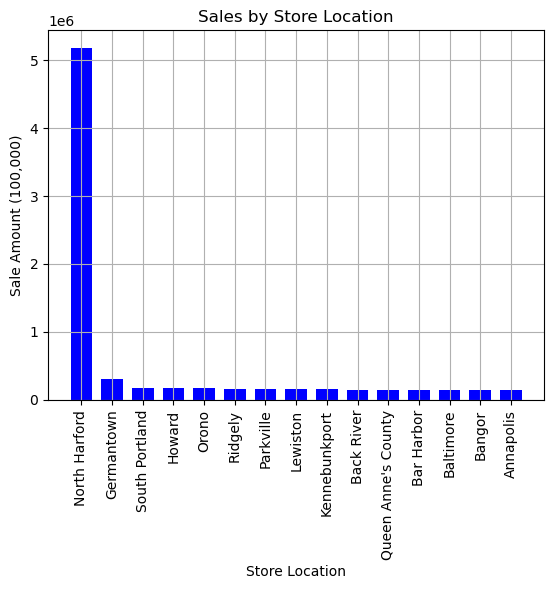

In [201]:

plt.bar(store_sales['Store Location'], store_sales['Sale Amount'], color='blue', width = 0.7)

plt.xlabel('Store Location')
plt.ylabel('Sale Amount (100,000)')
plt.title('Sales by Store Location')
plt.grid()
plt.xticks(rotation= 90)
plt.show()


I decided to show the rankings with both territories on the same plan so we can see a overall performance from both Maryland and Maine. I decided to work with the first merge I did because I felt I needed a fresh canvas to work with. Working the clean merge and keeping the Marketing Manager's question in mind, I decided to create the rank list based on how well their sells are doing.

### The Marketing Manager wants to know:
Comparing the customer ID from the customer list data with the rewards ID from the sales data,
who were the top customers in each sales territory?

In [49]:
cust.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,5/22/2023,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,7/9/2023,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,9/1/2023,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,11/18/2023,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [54]:
ss.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
12,1/1/2022,710,357.0,105360-T,188.20
14,1/1/2022,712,296.0,105362-B,17.70
17,1/1/2022,714,512.0,105365-T,221.48
18,1/1/2022,714,171.0,105351-M,44.00
29,1/1/2022,726,17.0,105381-M,55.00


In [76]:
customer = pd.merge(
    cust,
    ss,
    left_on='cust_id',
    right_on='RewardsID',
    how='inner'
)

customer.head()

,cust_id,date,time,name,email,phone,sms-opt-out,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N,1/11/2022,835,1.0,105351-M,44.00
1,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N,6/4/2022,806,1.0,105320-IT,30.16
2,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N,6/12/2022,736,1.0,105741-B,17.70
3,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N,6/29/2022,865,1.0,105902-T,134.56
4,1,3/15/2023,8:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N,9/7/2022,851,1.0,105460-IT,72.50


In [78]:
summary = (
    customer.groupby(['Store ID', 'cust_id', 'name'])['Sale Amount']
    .sum()
    .reset_index()
)
summary.head()

,Store ID,cust_id,name,Sale Amount
0,701,16,Gus Fring,4.32
1,701,31,Homer S.,2.88
2,701,34,Lisa S.,51.40
3,701,36,Ned Flanders,51.96
4,701,55,Will B.,5.24


In [84]:
summary['Rank'] = (
    summary.groupby('Store ID')['Sale Amount']
    .rank(method='dense', ascending=False)
)

summary.columns

Index(['Store ID', 'cust_id', 'name', 'Sale Amount', 'Rank'], dtype='object')

In [98]:

fs = summary[
    summary['Store ID'].isin(list(range(731, 740)) + list(range(818, 824)))
]
fs.head()

,Store ID,cust_id,name,Sale Amount,Rank
3421,731,12,Jesse Pinkman,71.44,25.0
3422,731,14,Saul Goodman,61.14,29.0
3423,731,17,Mike E.,24.28,44.0
3424,731,19,Todd,159.58,16.0
3425,731,23,Tyrion L.,39.75,37.0


In [91]:
top_customers = filtered_summary[summary['Rank'] == 1]

/tmp/ipykernel_144/4215132172.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top_customers = filtered_summary[summary['Rank'] == 1]


In [92]:
print(top_customers)

      Store ID  cust_id             name  Sale Amount  Rank
3436       731       99       Trent Lane      1717.70   1.0
3469       731      336       Hugo Reyes      1717.70   1.0
3473       731      367    Enid Sinclair      1717.70   1.0
3582       732      374       Josh Lyman      1717.70   1.0
3680       733      375       C.J. Cregg       873.30   1.0
3848       734      400    K. McClanahan      1376.44   1.0
3955       735      339         Sun Kwon      1763.70   1.0
4090       736      106      Bob Belcher      4507.06   1.0
4537       737      136    Victor Newman      1350.14   1.0
4656       738      168           Darius      1790.22   1.0
4766       739      165     Ken Franklin      1723.70   1.0
6724       818      396          Stan Z.      1717.70   1.0
6758       819       66      Jeff Winger      1981.04   1.0
6850       820       45        Angela M.      1300.44   1.0
7001       821      270   George Michael      1301.88   1.0
7096       822      292  Beverly Crusher

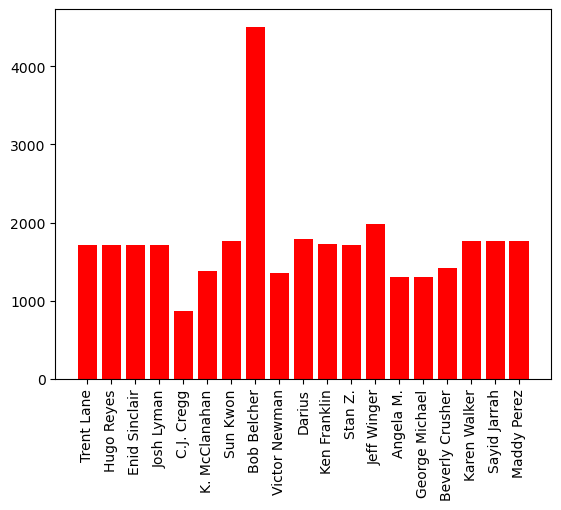

In [206]:
plt.bar(top_customers['name'], top_customers['Sale Amount'], color = 'red', width = .8) 
plt.xticks(rotation= 90)
plt.show()

To answer this question from the Marketing Manager I knew I needed to merge the customer list with the Store Sales file to properly see the full picture. After doing that I seen that I needed to show who was the top spender in each store for the territories so I used the rank function to easier see who ranks highest. Once I was done with the setup I was able to see the top customers all spent more than $800 which could help to start a VIP membership to encourage more customers to spend with goals of reaching said status.

### The Marketing Manager wants to know:

What is the number of transactions per month by product category in each assigned territory?
What is total sales revenue per month by category? What might this tell you about the most
popular products, and where could there be opportunity for growth?

In [93]:
prod.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [94]:
prod_cate.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [96]:
product = pd.merge(prod, prod_cate, on = 'CategoryID')
product.head()

,Prod Num,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory
0,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets
1,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-cal,Calculators
2,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-sof,Software Download
3,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-hea,Headphones
4,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-ext,External Accessories


In [102]:
ss.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
12,1/1/2022,710,357.0,105360-T,188.20
14,1/1/2022,712,296.0,105362-B,17.70
17,1/1/2022,714,512.0,105365-T,221.48
18,1/1/2022,714,171.0,105351-M,44.00
29,1/1/2022,726,17.0,105381-M,55.00


In [106]:
product_info = pd.merge(product, df_merge, on = 'Prod Num')
product_info.head()

,Prod Num,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory,Transaction Date,Store ID,RewardsID,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Month
0,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets,2022-01-14,736,257.0,883.48,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01
1,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets,2022-03-10,732,184.0,883.48,Back River,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-03
2,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets,2023-02-14,736,321.0,883.48,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2023-02
3,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets,2023-08-28,736,29.0,883.48,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2023-08
4,105248-IT,TCL NXTPAPER 10s,120,120-tab,Technology & Accessories,120-tab,Tablets,2023-10-10,737,482.0,883.48,Parkville,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2023-10


In [153]:

transactions = (
    product_info.groupby(['Month', 'Prod Num', 'Subcategory', 'Store ID', 'State'])
      .size()
      .reset_index(name='Transaction_Count')
)


In [160]:
transactions.head()

,Month,Prod Num,Store Location,Subcategory,Store ID,State,Transaction_Count
0,2022-01,105248-IT,North Harford,Calculators,736,Maryland,1
1,2022-01,105248-IT,North Harford,Chargers and Power Adapters,736,Maryland,1
2,2022-01,105248-IT,North Harford,External Accessories,736,Maryland,1
3,2022-01,105248-IT,North Harford,Headphones,736,Maryland,1
4,2022-01,105248-IT,North Harford,Laptops,736,Maryland,1


In [155]:

revenue = (
    product_info.groupby(['Month', 'Prod Num', 'Store Location', 'Subcategory'])['Sale Amount']
      .sum()
      .reset_index(name='Total Revenue')
)


In [159]:
revenue.head()

,Month,Prod Num,Store Location,Subcategory,Total Revenue
0,2022-01,105248-IT,North Harford,Calculators,883.48
1,2022-01,105248-IT,North Harford,Chargers and Power Adapters,883.48
2,2022-01,105248-IT,North Harford,External Accessories,883.48
3,2022-01,105248-IT,North Harford,Headphones,883.48
4,2022-01,105248-IT,North Harford,Laptops,883.48


After reviewing the data I see that North Harford has the most sells of all products among both Maine and Maryland. Out of all the products being sold I can see that the electronics sold the best compared to items like calculators chargers and headsets. I would recommend Emporium to opt in to selling more items like laptops, chargers, and tablets

## What Would I recommend the Marketing Manager

I would recommend that 